# SO100/SO101 Trajectory Explorer

This notebook explores and visualizes data from SO100/SO101 datasets, which have the following structure:

```
sample_directory/
├── metadata.json               # Metadata file with episode information
├── trajectory.h5               # HDF5 file containing robot trajectory data
└── recordings/MP4/
    └── front_camera.mp4        # Video recording from the front camera
```

The SO100/SO101 datasets have a specific structure in the trajectory.h5 file:
- `/observation/state`: Joint states [shoulder_pan, shoulder_lift, elbow_flex, wrist_flex, wrist_roll, gripper]
- `/action/data`: Robot actions
- `/metadata/timestamp`: Timestamps for each frame

This notebook will:
1. Explore the file structure of a sample episode
2. Visualize the joint trajectories in separate plots:
   - Position (shoulder and elbow joints)
   - Orientation (wrist joints)
   - Gripper state
3. Display video frames from the episode recording

Note: This notebook can also check for V-JEPA 2-AC compatibility, which requires a different data structure.

In [ ]:
#!/usr/bin/env python3
import os
import sys
import json
import glob
import h5py
import numpy as np
import matplotlib.pyplot as plt
import cv2
from pathlib import Path
from scipy.spatial.transform import Rotation
import torch

from lerobot_so_arm.config import get_path
vjepa_root = get_path('vjepa_root')
sys.path.append(vjepa_root)

from app.vjepa_droid.droid import get_json, DROIDVideoDataset
from app.vjepa_droid.transforms import make_transforms
from decord import VideoReader, cpu

# Import our custom utility functions
from utils.data_loading import check_vjepa2ac_format, analyze_metadata, load_traj_from_HDF5

## Set Target Sample Folder Path

Specify the path to a sample directory that follows the V-JEPA 2-AC expected structure. This should point to a single episode/trajectory from the SO100/SO101 dataset.

In [ ]:
SOURCE_FOLDER = get_path('datasets') + '/source'
OUTPUT_FOLDER = get_path('datasets') + '/output'
target_sample_path = OUTPUT_FOLDER + '/episodes/episode_001'
print(f"Target sample directory: {target_sample_path}")
is_valid, message = check_vjepa2ac_format(target_sample_path)
print (f"{message}")


Target sample directory: /teamspace/studios/this_studio/test_dataset/source/episodes/smanni+train_so100_all-episode_001
Directory follows SO100/SO101 format.


## Load Metadata from JSON Files

Find and load any JSON metadata files in the sample directory using the V-JEPA `get_json` function.

In [21]:
# Use our utility function to analyze the metadata
metadata_analysis = analyze_metadata(target_sample_path)
print(metadata_analysis)

# Also load the metadata for later use
metadata = get_json(target_sample_path)

SO100/SO101 Dataset Analysis
--------------------------
Episode ID: 1
Episode Name: smanni+train_so100_all-episode_001
Source Dataset: smanni+train_so100_all
Total Frames: 598
Duration: 19.933333333333334 seconds
FPS: 30

Data Keys:
- action: {'shape': [6], 'dtype': 'float32', 'names': ['shoulder_pan.pos', 'shoulder_lift.pos', 'elbow_flex.pos', 'wrist_flex.pos', 'wrist_roll.pos', 'gripper.pos']}
- observation.state: {'shape': [6], 'dtype': 'float32', 'names': ['shoulder_pan.pos', 'shoulder_lift.pos', 'elbow_flex.pos', 'wrist_flex.pos', 'wrist_roll.pos', 'gripper.pos']}

Files:
- trajectory: trajectory.h5
- video: {'front_camera': 'recordings/MP4/front_camera.mp4'}

Trajectory Analysis:
File: /teamspace/studios/this_studio/test_dataset/source/episodes/smanni+train_so100_all-episode_001/trajectory.h5
Top-level groups: ['action', 'metadata', 'observation']

Joint States:
- Shape: (598, 6)
- Type: float32
- Components: [shoulder_pan, shoulder_lift, elbow_flex, wrist_flex, wrist_roll, gripp

## Load Trajectory Data from HDF5 File

Open and explore the structure of the trajectory.h5 file to understand the robot state data.

In [22]:
# Path to the trajectory.h5 file
trajectory_path = os.path.join(target_sample_path, "trajectory.h5")

# Use the new load_traj_from_HDF5 function to load the trajectory data
try:
    trajectory_data = load_traj_from_HDF5(trajectory_path)
except Exception as e:
    print(f"Error loading trajectory data: {e}")
    import traceback
    traceback.print_exc()

Successfully opened: /teamspace/studios/this_studio/test_dataset/source/episodes/smanni+train_so100_all-episode_001/trajectory.h5

SO100/SO101 compatibility check:
✓ Joint states (/observation/state): Found
✓ Timestamps (/metadata/timestamp): Found
✓ Actions (/action/data): Found

V-JEPA 2-AC compatibility check:
✓ robot_state/cartesian_position: Missing
✓ robot_state/gripper_position: Missing

Joint states shape: (598, 6)

Joint state components for SO100/SO101:
  Index 0: shoulder_pan (rad)
  Index 1: shoulder_lift (rad)
  Index 2: elbow_flex (rad)
  Index 3: wrist_flex (rad)
  Index 4: wrist_roll (rad)
  Index 5: gripper_position (0-1)


## Visualize SO Trajectory Data

Plot the robot trajectory data over time to better understand the movement.

Using joint states with shape: (598, 6)
Using timestamps with shape: (598,)


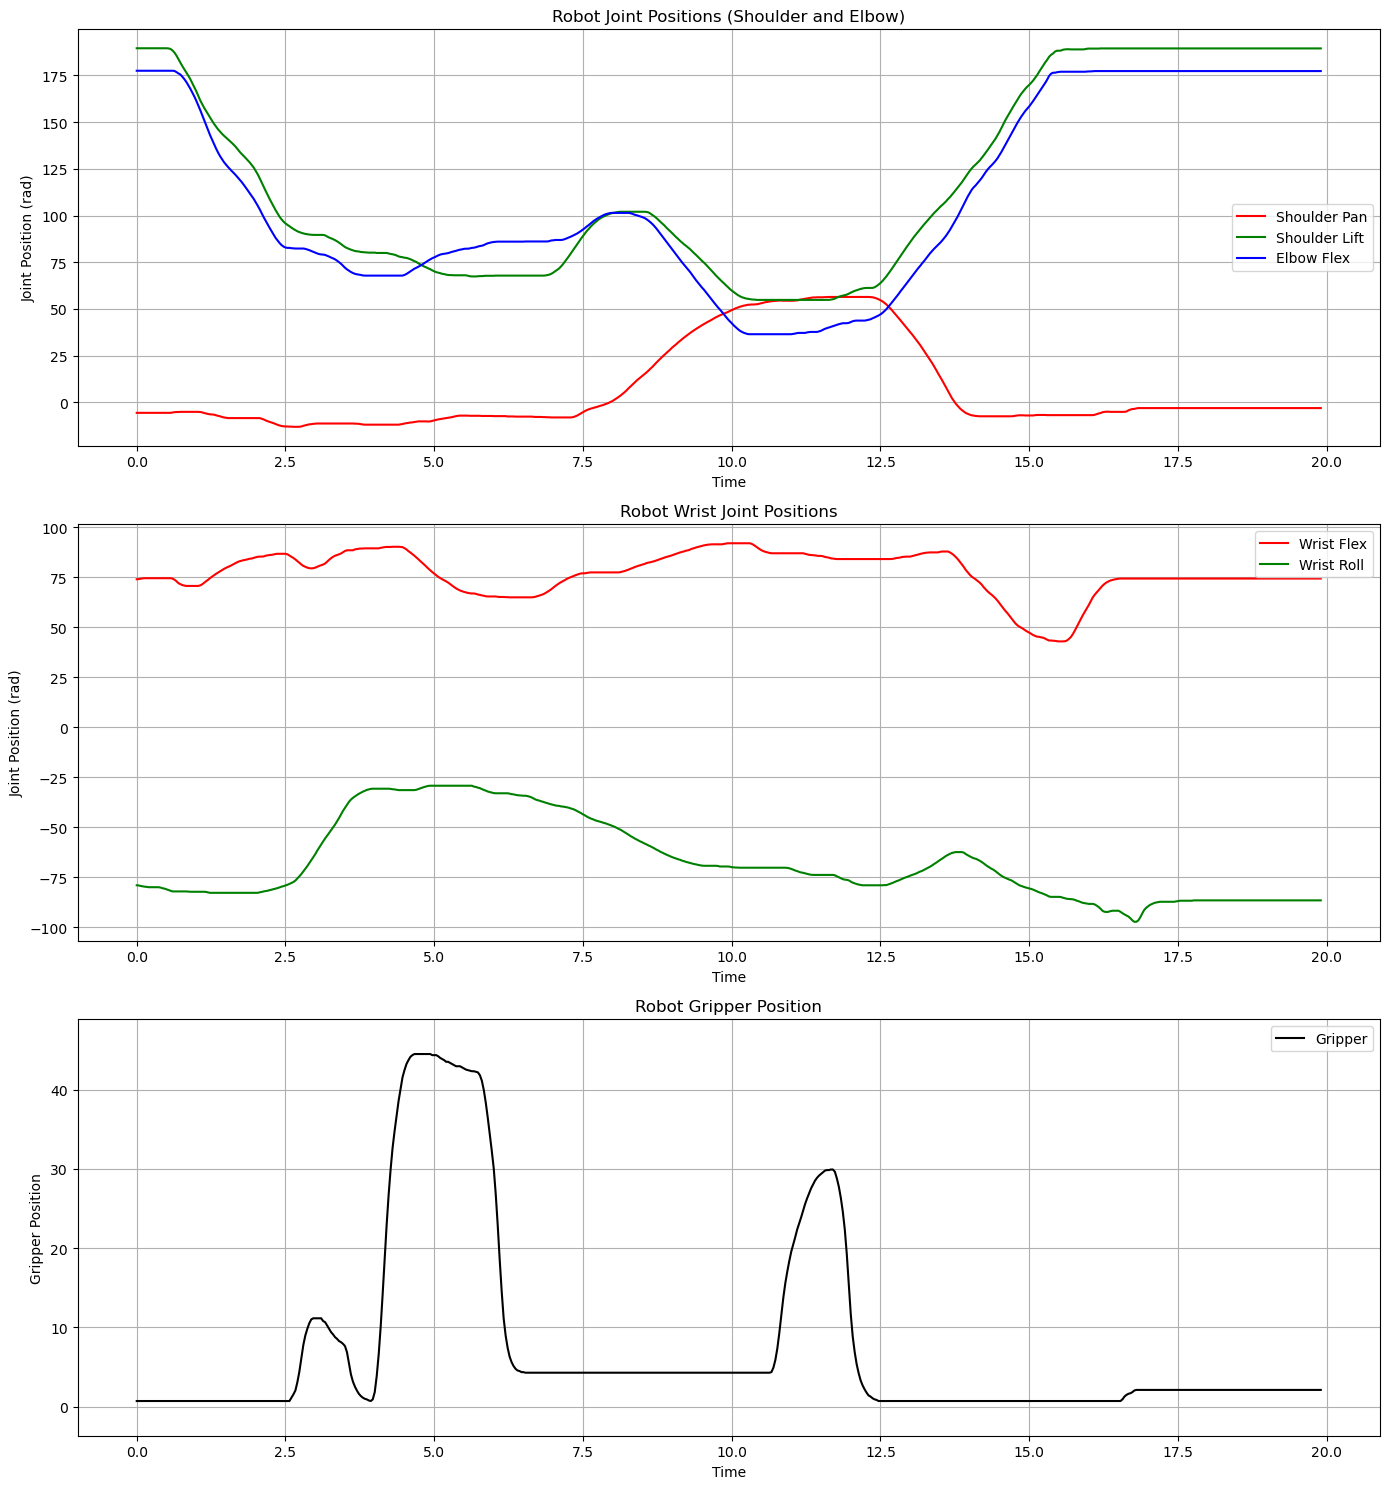


Trajectory Statistics:
Total duration: 598 timesteps
Joint angle ranges:
  Shoulder Pan: [-13.0957, 56.4258] rad
  Shoulder Lift: [54.8438, 189.5801] rad
  Elbow Flex: [36.4746, 177.5391] rad
  Wrist Flex: [42.9785, 92.1094] rad
  Wrist Roll: [-97.3828, -29.2676] rad
  Gripper: [0.7008, 44.4990]

Note: To visualize the robot trajectory in 3D space, we would need to apply
forward kinematics to convert joint angles to end-effector positions.
You can use the utils.kinematics.RobotKinematics class for this purpose.


In [23]:
# Visualize the trajectory data using the trajectory_data object created earlier
# This avoids reopening the file unnecessarily

# Import the visualization function from the utils module
from utils.visualization import visualize_so_trajectory
try:
    # Use the visualize_so_trajectory function to create plots and print statistics
    # Note: joint_states already includes gripper position as the 6th column
    stats = visualize_so_trajectory(
        joint_states=trajectory_data['joint_states'],
        timestamps=trajectory_data.get('timestamps'),
        title="SO100/SO101 Robot Trajectory"
    )
    
except Exception as e:
    print(f"Error processing trajectory data: {e}")
    import traceback
    traceback.print_exc()